In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Наложение и удаление шума

In [2]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

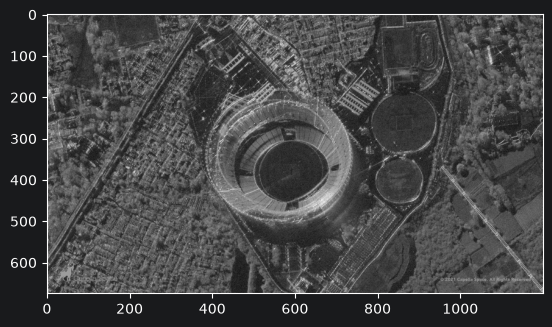

In [3]:
plt.imshow(image_gray, cmap="gray")

In [4]:
# Gaussian noise
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ..., 111,   0,  80],
       [  1, 104,  68, ...,   0, 103,   0],
       [  0,   0,  51, ...,   0,   0, 145],
       ...,
       [  0,   0,  39, ..., 255,   0,  15],
       [  0,  34,   0, ...,   0,   5, 135],
       [160, 204,   0, ...,  21,   0, 109]],
      shape=(675, 1200), dtype=uint8)

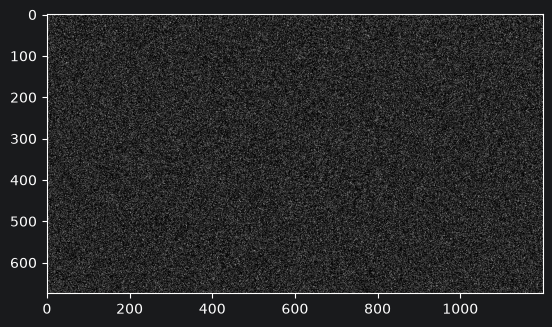

In [5]:
plt.imshow(noise_gauss, cmap="gray")

In [6]:
# Salt and pepper
noise =  np.random.randint(0, 101, size = (image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

In [7]:
bg_image = np.ones(image_gray.shape, np.uint8) * 128

In [8]:
bg_image[zeros_pixel] = 0
bg_image[ones_pixel] = 255

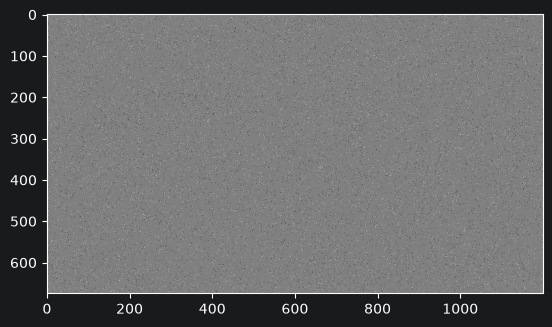

In [9]:
plt.imshow(bg_image, cmap="gray")

In [10]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)

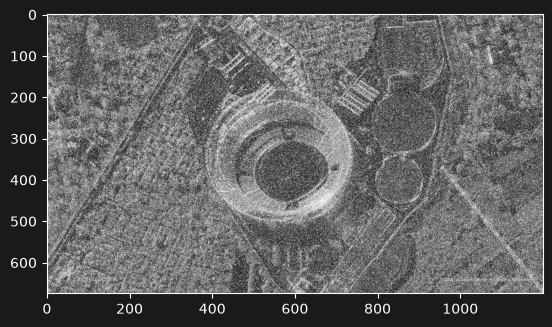

In [11]:
plt.imshow(image_noise_gauss, cmap="gray")

In [12]:
from skimage.metrics import structural_similarity, mean_squared_error
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim)

4230.673058024691 0.18699266800035377


In [13]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)

In [14]:
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray,  image_gauss_median, full=True)

In [15]:
print(mse_gauss_median, ssim_gauss_median)

1038.0453432098766 0.42824305715634176


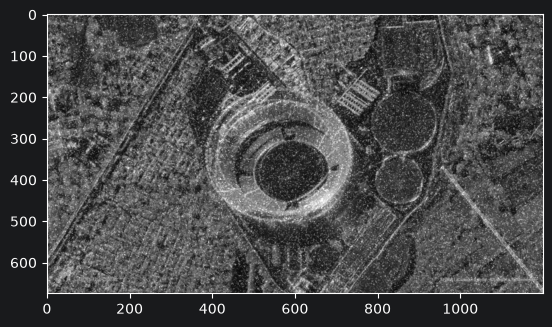

In [16]:
plt.imshow(image_gauss_median, cmap="gray")

In [17]:
import copy

image_sp = copy.deepcopy(image_gray)

image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

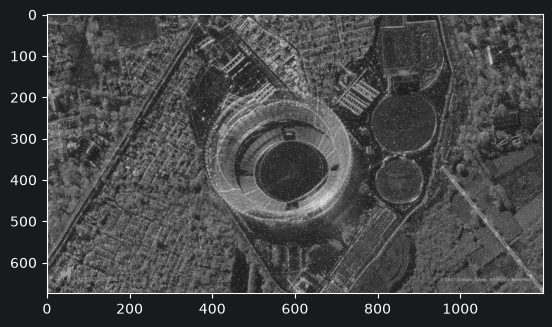

In [18]:
plt.imshow(image_sp, cmap="gray")

In [19]:
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

396.12326172839505 0.7169555440774041


In [20]:
image_sp_median = cv2.medianBlur(image_sp, 3)

In [21]:
mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print(mse_sp_median, ssim_sp_median)

95.8497975308642 0.8160148541142088


# Другие типы фильтров

In [22]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss,(5,5),0)

In [23]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss,9,75,75)

In [24]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)

In [25]:
import math

def geom(a):
    prod = 1
    for i in range(a.shape[0]):
        prod1 = 1
        for j in range(a.shape[1]):
            prod1 *= a[i,j]
        prod1 = math.pow(prod1, 1.0/9.0)
        prod *= prod1
    return prod

def proc(img, filter):
    img_res = copy.deepcopy(img)
    for i in range(0,img.shape[0] -2):
        for j in range(0,img.shape[1] -2):
            img_res[i:i+3, j:j+3] = filter(img[i:i+3, j:j+3])
    return img_res
    
res = proc(image_noise_gauss, geom)


C:\Users\roman\AppData\Local\Temp\ipykernel_47224\164976186.py:8: RuntimeWarning: overflow encountered in scalar multiply
  prod1 *= a[i,j]


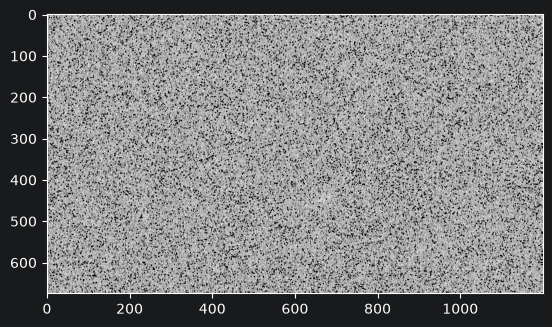

In [26]:
plt.imshow(res, cmap="gray")

In [27]:
mse_geom = mean_squared_error(image_gray, res)
(ssim_geom, diff) = structural_similarity(image_gray, res, full=True)
print(mse_geom, ssim_geom)

6551.976648148148 0.02746126776511089



# 2D свертка

In [28]:
# averaging filter
kernel_5 = np.ones((5,5),np.float32)/25
image_k5 = cv2.filter2D(image_gray,-1,kernel_5)
# blured_image = cv2.blur(img,(5,5))
image_b5 = cv2.blur(image_gray,(5,5))

In [29]:
mse_kb = mean_squared_error(image_k5, image_b5)
(ssim_kb, diff) = structural_similarity(image_k5, image_b5, full=True)
print(mse_kb, ssim_kb)

0.0 1.0


In [30]:
# Laplasian
kernel_lapl = np.array([[0,-10,0],
                        [-10,40,-10],
                        [0,-10,0]], np.float32)

In [31]:
image_lapl = cv2.filter2D(image_gray,-1,kernel_lapl) 

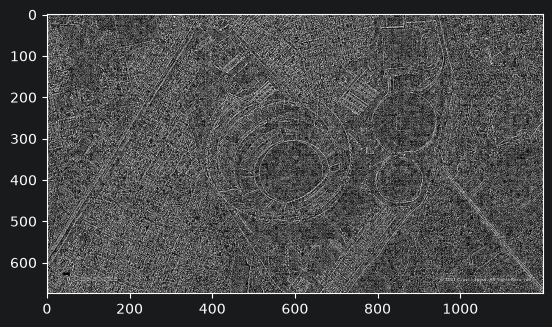

In [32]:
plt.imshow(image_lapl, cmap="gray")

In [33]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

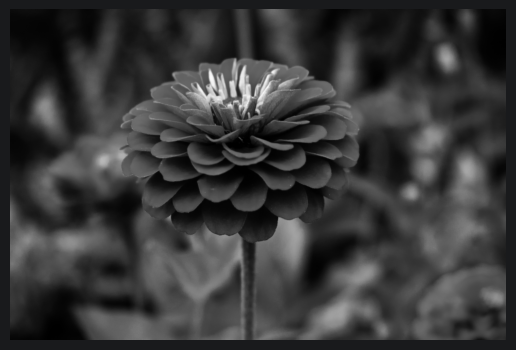

In [34]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image_hw = cv2.imread('img.jpg')
image_hw_gray = cv2.cvtColor(image_hw, cv2.COLOR_BGR2GRAY)

plt.imshow(image_hw_gray, cmap='gray')
plt.axis('off')
plt.show()

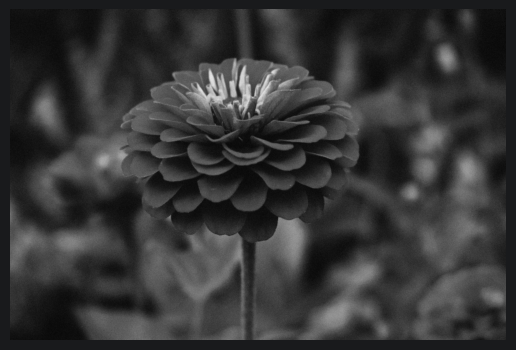

In [35]:
# Gaussian noise
mean = 0
stddev = 30

noise_gauss = np.random.normal(
    mean,
    stddev,
    image_hw_gray.shape
)

image_hw_gauss = image_hw_gray.astype(np.float32) + noise_gauss
image_hw_gauss = np.clip(image_hw_gauss, 0, 255).astype(np.uint8)

plt.imshow(image_hw_gauss, cmap='gray')
plt.axis('off')
plt.show()

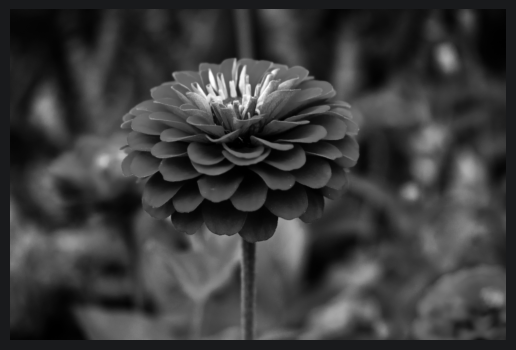

In [36]:
constant = 30

image_hw_constant = image_hw_gray.astype(np.int16) + constant
image_hw_constant = np.clip(image_hw_constant, 0, 255).astype(np.uint8)

plt.imshow(image_hw_constant, cmap='gray')
plt.axis('off')
plt.show()

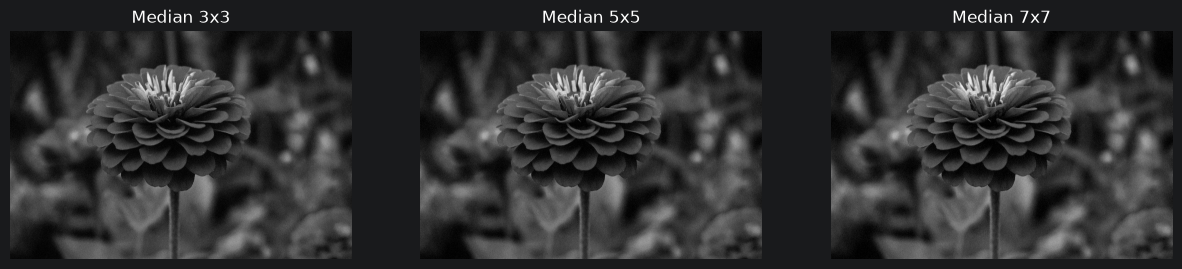

In [37]:
median_3 = cv2.medianBlur(image_hw_gauss, 3)
median_5 = cv2.medianBlur(image_hw_gauss, 5)
median_7 = cv2.medianBlur(image_hw_gauss, 7)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(median_3, cmap='gray')
plt.title('Median 3x3')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(median_5, cmap='gray')
plt.title('Median 5x5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(median_7, cmap='gray')
plt.title('Median 7x7')
plt.axis('off')

plt.show()

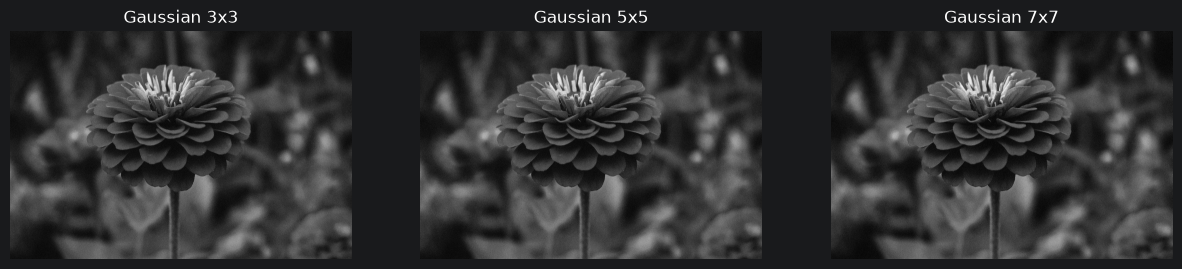

In [38]:
gauss_3 = cv2.GaussianBlur(image_hw_gauss, (3, 3), 0)
gauss_5 = cv2.GaussianBlur(image_hw_gauss, (5, 5), 0)
gauss_7 = cv2.GaussianBlur(image_hw_gauss, (7, 7), 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gauss_3, cmap='gray')
plt.title('Gaussian 3x3')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gauss_5, cmap='gray')
plt.title('Gaussian 5x5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gauss_7, cmap='gray')
plt.title('Gaussian 7x7')
plt.axis('off')

plt.show()

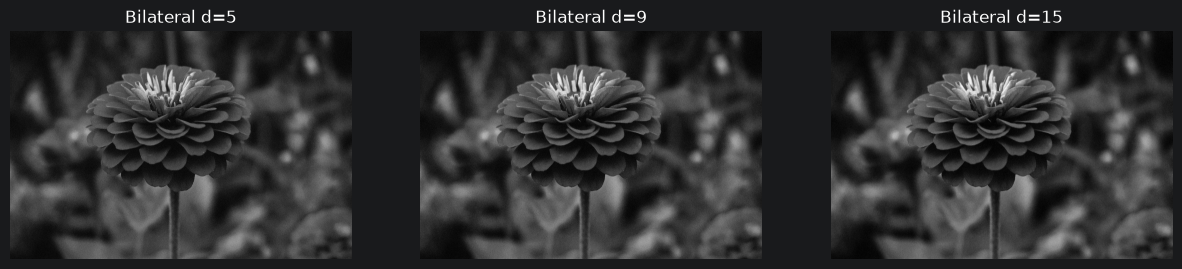

In [39]:
bilateral_1 = cv2.bilateralFilter(image_hw_gauss, 5, 30, 30)
bilateral_2 = cv2.bilateralFilter(image_hw_gauss, 9, 50, 50)
bilateral_3 = cv2.bilateralFilter(image_hw_gauss, 15, 75, 75)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(bilateral_1, cmap='gray')
plt.title('Bilateral d=5')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(bilateral_2, cmap='gray')
plt.title('Bilateral d=9')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(bilateral_3, cmap='gray')
plt.title('Bilateral d=15')
plt.axis('off')

plt.show()

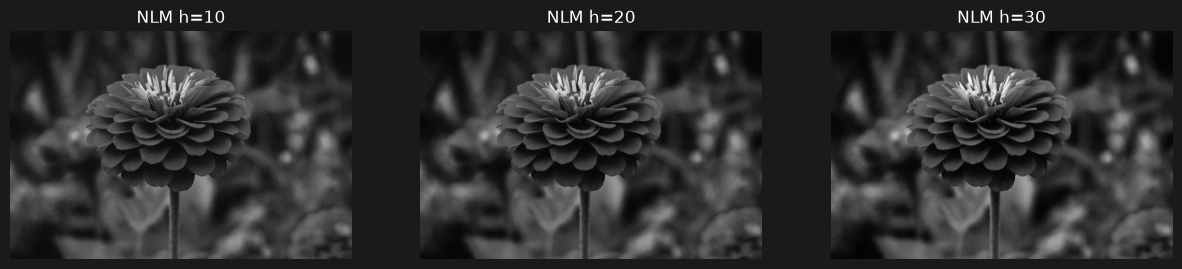

In [40]:
nlm_1 = cv2.fastNlMeansDenoising(image_hw_gauss, None, 10, 7, 21)
nlm_2 = cv2.fastNlMeansDenoising(image_hw_gauss, None, 20, 7, 21)
nlm_3 = cv2.fastNlMeansDenoising(image_hw_gauss, None, 30, 7, 21)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(nlm_1, cmap='gray')
plt.title('NLM h=10')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(nlm_2, cmap='gray')
plt.title('NLM h=20')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(nlm_3, cmap='gray')
plt.title('NLM h=30')
plt.axis('off')

plt.show()

In [41]:
from skimage.metrics import mean_squared_error, structural_similarity

filters = {
    'Median 3x3': median_3,
    'Gaussian 3x3': gauss_3,
    'Bilateral d=5': bilateral_1,
    'NLM h=10': nlm_1
}

for name, filtered in filters.items():
    mse = mean_squared_error(image_hw_gray, filtered)
    ssim = structural_similarity(image_hw_gray, filtered)

    print(f'{name}: MSE = {mse:.2f}, SSIM = {ssim:.4f}')

Median 3x3: MSE = 150.39, SSIM = 0.3492
Gaussian 3x3: MSE = 121.53, SSIM = 0.4152
Bilateral d=5: MSE = 287.20, SSIM = 0.2370
NLM h=10: MSE = 755.76, SSIM = 0.1079
